In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import time,datetime,date
from pathlib import Path

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120

root = Path.home() / "Data" / "binance"
feat_dir = root / "features"

## Load Data

In [2]:
# 1m features (pre-computed)
feat = pd.read_parquet(feat_dir / "1m" / "BTCUSDT.parquet")
print(f"Features: {len(feat):,} rows, {feat.index.min()} -> {feat.index.max()}")

# Raw spot 1m (for 20-day realized vol)
spot_files = sorted((root / "spot" / "klines" / "1m" / "BTCUSDT").glob("*.parquet"))
spot = pd.concat([pd.read_parquet(f) for f in spot_files], ignore_index=True)
spot = spot.sort_values("open_time").drop_duplicates(subset=["open_time"])
spot.index = pd.to_datetime(spot["open_time"], unit="ms", utc=True)
spot["close"] = pd.to_numeric(spot["close"], errors="coerce").astype("float64")
print(f"Spot: {len(spot):,} rows")

# Raw futures 1m (for forward returns)
fut_files = sorted((root / "futures_um" / "klines" / "1m" / "BTCUSDT").glob("*.parquet"))
fut = pd.concat([pd.read_parquet(f) for f in fut_files], ignore_index=True)
fut = fut.sort_values("open_time").drop_duplicates(subset=["open_time"])
fut.index = pd.to_datetime(fut["open_time"], unit="ms", utc=True)
fut["close"] = pd.to_numeric(fut["close"], errors="coerce").astype("float64")
print(f"Futures: {len(fut):,} rows")

Features: 3,286,080 rows, 2020-01-01 00:00:00+00:00 -> 2026-03-31 23:59:00+00:00
Spot: 4,284,575 rows
Futures: 3,286,080 rows


## Build Signal & PnL

In [3]:
# Signal: basis_zscore_50d (demean 50d, devol 20d) from pre-computed features
signal = feat["BTCUSDT_basis_zscore_50d"].copy()

# Spot 20-day realized volatility (20 * 1440 = 28800 bars)
spot_log_ret = np.log(spot["close"] / spot["close"].shift(1))
spot_vol_20d = spot_log_ret.rolling(20 * 1440, min_periods=1440).std()

# Futures 1m log return, lagged 10 minutes forward
fut_ret_1m = np.log(fut["close"] / fut["close"].shift(1))
ret_forward_10 = fut_ret_1m.shift(-10)

# Align
common = (
    signal.dropna().index
    .intersection(spot_vol_20d.dropna().index)
    .intersection(ret_forward_10.dropna().index)
)
print(f"Common timestamps: {len(common):,}  ({common.min()} -> {common.max()})")

sig = signal.loc[common]
vol = spot_vol_20d.loc[common]
ret = ret_forward_10.loc[common]

# Position: short basis (mean-reversion), vol-scaled, clipped
position = -sig / vol.clip(lower=1e-12)
position = position.clip(-10, 10)

# PnL
pnl = position * ret
cum_pnl = pnl.cumsum()

Common timestamps: 3,239,111  (2020-01-01 00:04:00+00:00 -> 2026-02-28 23:59:00+00:00)


<Axes: xlabel='time'>

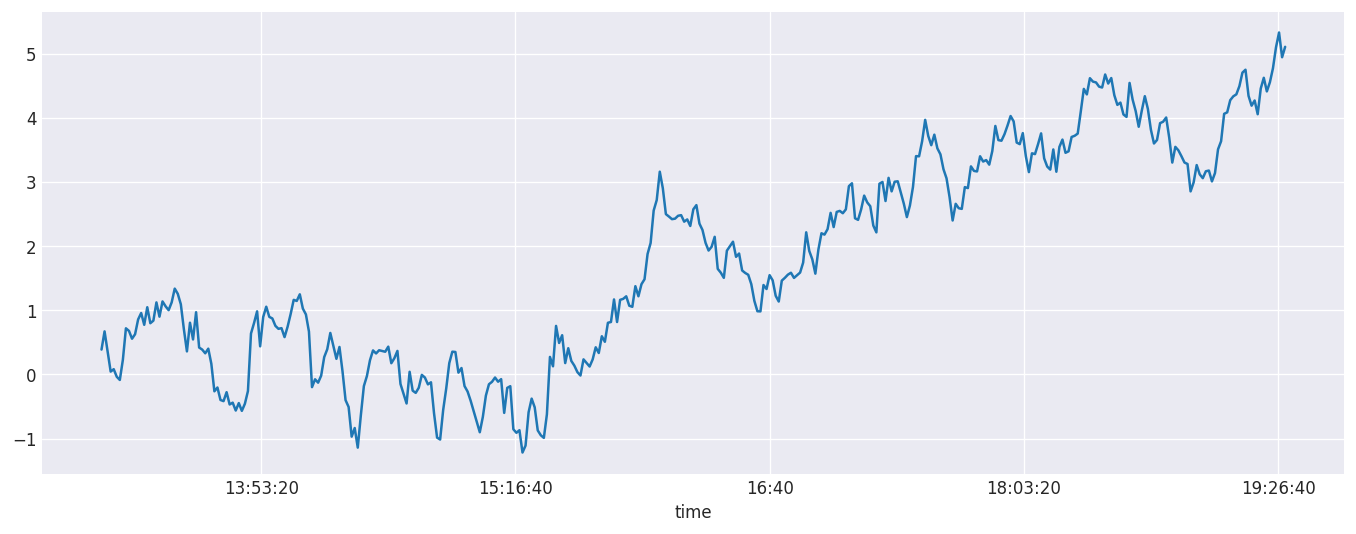

In [14]:
pnlAfter2023=pnl[pnl.index.year>2023]
pnlAfter2023=pnlAfter2023[pnlAfter2023.index.time>time(13,0,0)]
pnlAfter2023=pnlAfter2023[pnlAfter2023.index.time<time(19,30,0)]

pnlAfter2023.groupby(pnlAfter2023.index.time).sum().cumsum().plot()


<Axes: >

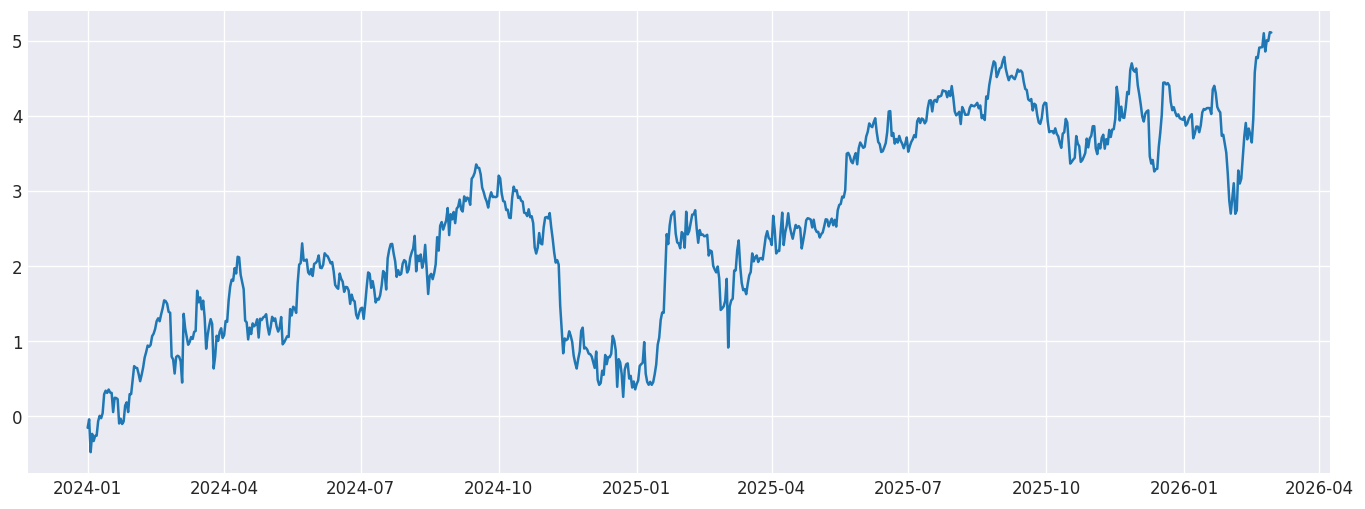

In [15]:
pnlAfter2023.groupby(pnlAfter2023.index.date).sum().cumsum().plot()

## Summary Statistics

In [4]:
bars_per_year = 365.25 * 24 * 60
total_years = len(pnl) / bars_per_year
sharpe = pnl.mean() / pnl.std() * np.sqrt(bars_per_year)
drawdown = cum_pnl - cum_pnl.cummax()

print(f"Total bars:        {len(pnl):,} ({total_years:.2f} years)")
print(f"Cumulative PnL:    {cum_pnl.iloc[-1]:.4f}")
print(f"Annualized Sharpe: {sharpe:.2f}")
print(f"Max Drawdown:      {drawdown.min():.4f}")
print(f"Hit Rate:          {(pnl > 0).mean():.4f}")
print()

# By-year breakdown
rows = []
for year in sorted(common.year.unique()):
    mask = common.year == year
    p = pnl.loc[common[mask]]
    yr_sharpe = p.mean() / p.std() * np.sqrt(bars_per_year) if p.std() > 0 else 0
    rows.append({"Year": year, "PnL": p.sum(), "Sharpe": yr_sharpe,
                 "Hit%": (p > 0).mean(), "Bars": len(p)})
yearly = pd.DataFrame(rows).set_index("Year")
print(yearly.to_string(float_format="{:.2f}".format))

Total bars:        3,239,111 (6.16 years)
Cumulative PnL:    44.8601
Annualized Sharpe: 1.08
Max Drawdown:      -7.5952
Hit Rate:          0.4936

       PnL  Sharpe  Hit%    Bars
Year                            
2020 11.16    1.37  0.50  525784
2021 10.60    1.09  0.50  524607
2022 19.30    2.90  0.50  525600
2023  3.86    0.86  0.48  525520
2024 -3.52   -0.63  0.50  527040
2025  3.22    0.70  0.49  525600
2026  0.23    0.25  0.49   84960


## Validate: Independent Recompute vs Pre-computed Features

In [ ]:
EWM_SPANS = (1, 5, 10, 30, 50)
BASIS_DEMEAN_DAYS = (1, 5, 10, 30, 50)
BASIS_DEVOL_DAYS = 20
ROLLING_WINDOW = 20
ZSCORE_WINDOW = 100
ZSCORE_MIN_PERIODS = 5
VOLUME_DIFF_EWM_SPAN = 20
EPS = 1e-12
SYMBOL = "BTCUSDT"
BARS_PER_DAY = 1440  # 1m resolution

def zscore_100bar(s):
    mu = s.rolling(ZSCORE_WINDOW, min_periods=ZSCORE_MIN_PERIODS).mean()
    sigma = s.rolling(ZSCORE_WINDOW, min_periods=ZSCORE_MIN_PERIODS).std().clip(lower=EPS)
    return (s - mu) / sigma

# --- Recompute base features from raw futures ---
log_ret = np.log(fut["close"] / fut["close"].shift(1))

recomp = pd.DataFrame(index=fut.index)

for s in EWM_SPANS:
    raw = log_ret.ewm(span=s, adjust=False).mean()
    recomp[f"{SYMBOL}_ewm_ret_{s}"] = zscore_100bar(raw)

raw_rvol = log_ret.rolling(ROLLING_WINDOW).std()
recomp[f"{SYMBOL}_realized_volatility"] = zscore_100bar(raw_rvol)

vol_mean = fut["volume"].astype("float64").rolling(ROLLING_WINDOW).mean().clip(lower=EPS)
raw_nvol = fut["volume"].astype("float64") / vol_mean
recomp[f"{SYMBOL}_norm_volume"] = zscore_100bar(raw_nvol)

imbalance = (2.0 * fut["taker_buy_base"].astype("float64") - fut["volume"].astype("float64")) / fut["volume"].astype("float64").clip(lower=EPS)
for s in EWM_SPANS:
    raw = imbalance.ewm(span=s, adjust=False).mean()
    recomp[f"{SYMBOL}_ewm_imbalance_{s}"] = zscore_100bar(raw)

# --- Recompute cross-market features ---
common_idx = fut.index.intersection(spot.index)
fut_c = fut.loc[common_idx]
spot_c = spot.loc[common_idx]

basis_raw = (fut_c["close"] - spot_c["close"]) / spot_c["close"].clip(lower=EPS)
devol_win = max(BASIS_DEVOL_DAYS * BARS_PER_DAY, 2)
basis_std = basis_raw.rolling(devol_win, min_periods=min(ZSCORE_MIN_PERIODS, devol_win)).std().clip(lower=EPS)

for d in BASIS_DEMEAN_DAYS:
    demean_win = max(d * BARS_PER_DAY, 2)
    mp = min(ZSCORE_MIN_PERIODS, demean_win)
    basis_mean = basis_raw.rolling(demean_win, min_periods=mp).mean()
    recomp.loc[common_idx, f"{SYMBOL}_basis_zscore_{d}d"] = (basis_raw - basis_mean) / basis_std

volume_diff_raw = np.log(fut_c["volume"].astype("float64") + 1) - np.log(spot_c["volume"].astype("float64") + 1)
volume_diff_smooth = volume_diff_raw.ewm(span=VOLUME_DIFF_EWM_SPAN, adjust=False).mean()
recomp.loc[common_idx, f"{SYMBOL}_volume_diff_z"] = zscore_100bar(volume_diff_smooth)

fut_imb = (2.0 * fut_c["taker_buy_base"].astype("float64") - fut_c["volume"].astype("float64")) / fut_c["volume"].astype("float64").clip(lower=EPS)
spot_imb = (2.0 * spot_c["taker_buy_base"].astype("float64") - spot_c["volume"].astype("float64")) / spot_c["volume"].astype("float64").clip(lower=EPS)
imb_diff = fut_imb - spot_imb

for s in EWM_SPANS:
    raw = imb_diff.ewm(span=s, adjust=False).mean()
    recomp.loc[common_idx, f"{SYMBOL}_ewm_imbalance_diff_{s}"] = zscore_100bar(raw)

print(f"Recomputed shape: {recomp.shape}")
print(f"Pre-computed shape: {feat.shape}")

# --- Compare ---
shared_cols = sorted(set(recomp.columns) & set(feat.columns))
shared_idx = recomp.index.intersection(feat.index)
print(f"Shared columns: {len(shared_cols)}, shared rows: {len(shared_idx):,}")

corrs = {}
for col in shared_cols:
    a = recomp.loc[shared_idx, col].astype("float64")
    b = feat.loc[shared_idx, col].astype("float64")
    valid = a.notna() & b.notna()
    if valid.sum() > 100:
        corrs[col] = a[valid].corr(b[valid])
    else:
        corrs[col] = np.nan

corr_df = pd.Series(corrs).sort_values()
print(f"\n{'Feature':<45} {'Corr':>8}")
print("-" * 55)
for name, c in corr_df.items():
    print(f"{name:<45} {c:>8.6f}")

print(f"\n>>> Min correlation: {corr_df.min():.6f}  ({corr_df.idxmin()})")
print(f">>> Mean correlation: {corr_df.mean():.6f}")
print(f">>> All > 0.999: {(corr_df > 0.999).all()}")

## Plots

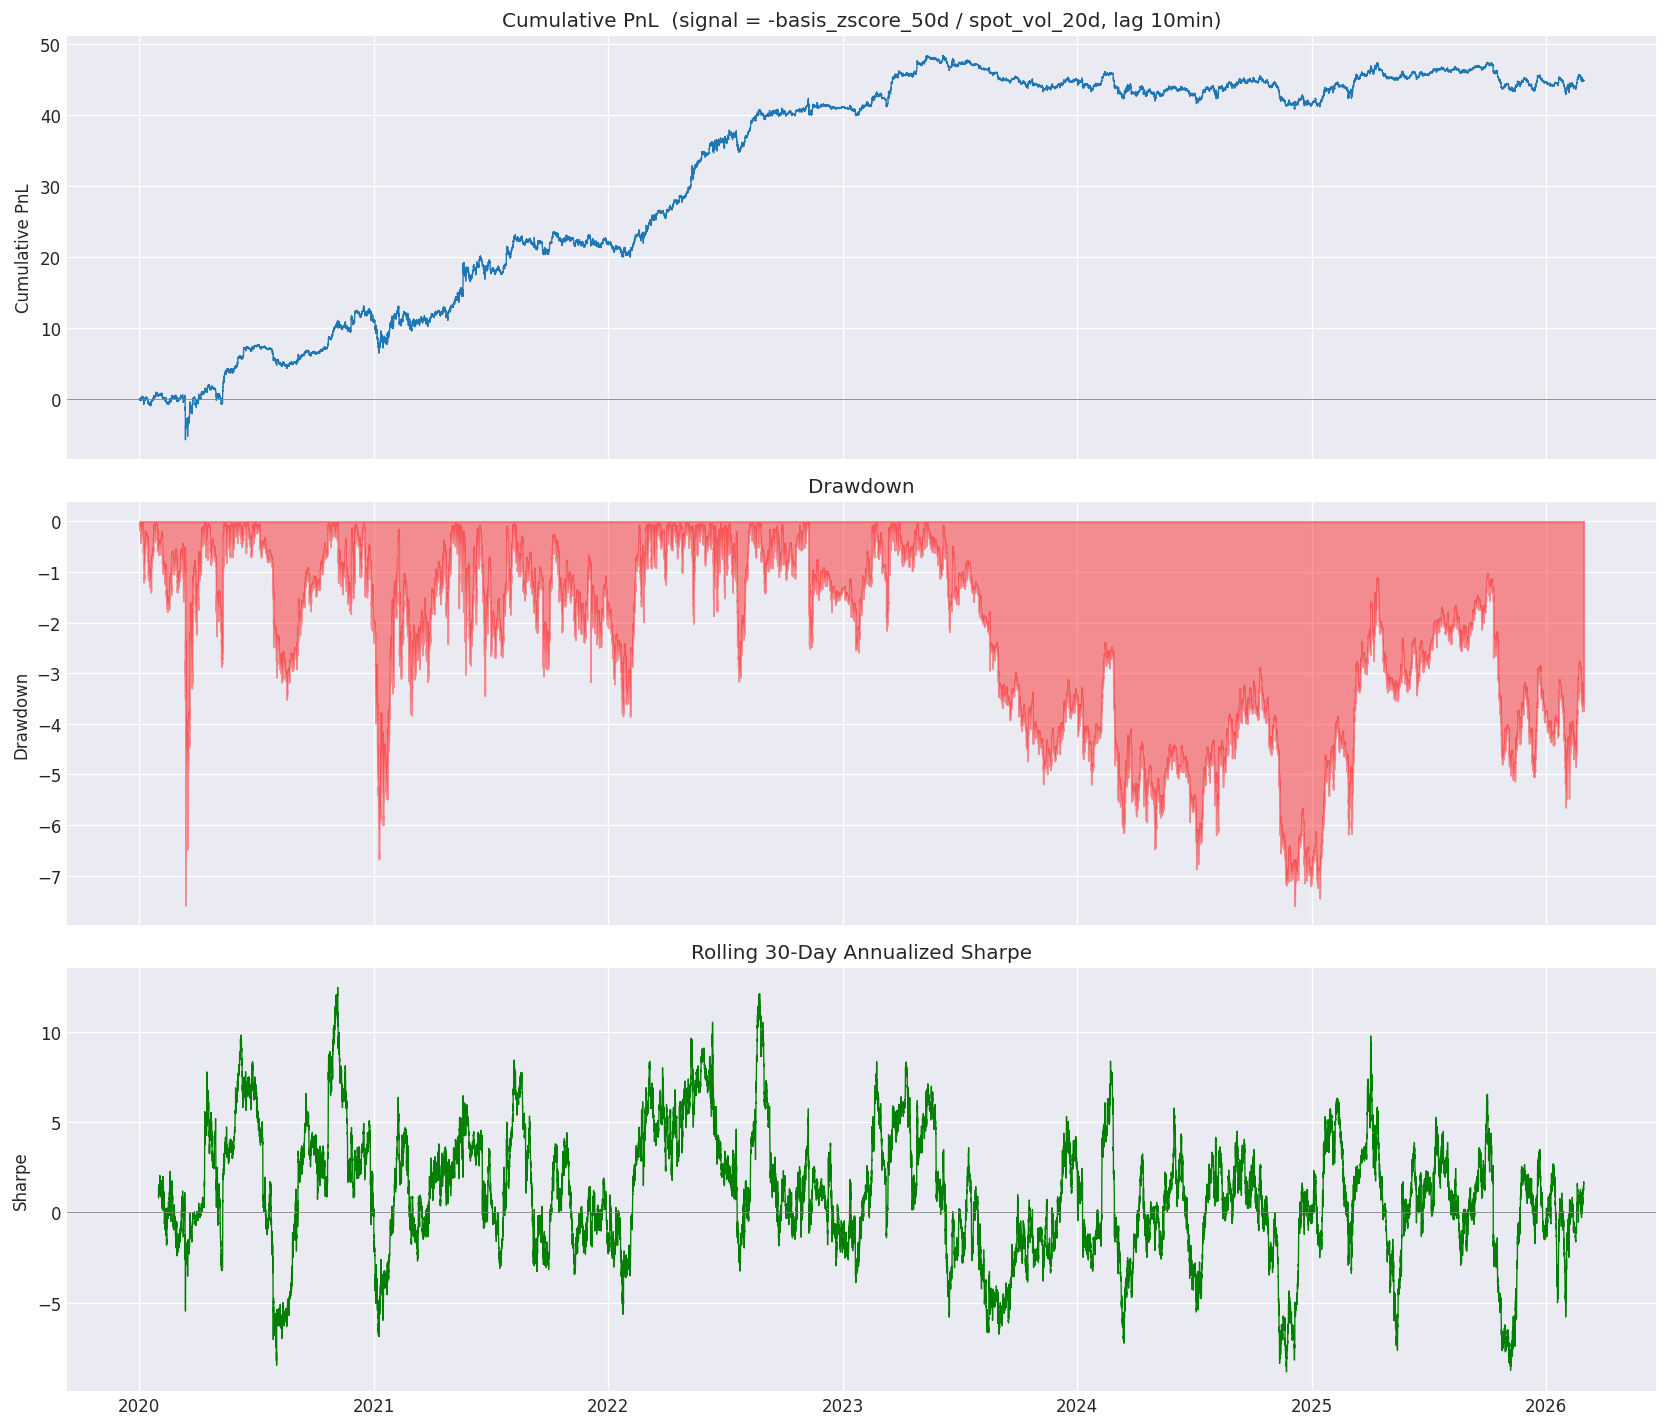

In [5]:
# Downsample to hourly for plotting (1m is too dense)
cum_pnl_h = cum_pnl.resample("1h").last().dropna()
dd_h = drawdown.resample("1h").min().dropna()

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# 1. Cumulative PnL
axes[0].plot(cum_pnl_h.index, cum_pnl_h.values, linewidth=0.8)
axes[0].set_title("Cumulative PnL  (signal = -basis_zscore_50d / spot_vol_20d, lag 10min)")
axes[0].set_ylabel("Cumulative PnL")
axes[0].axhline(0, color="gray", linewidth=0.5)

# 2. Drawdown
axes[1].fill_between(dd_h.index, dd_h.values, 0, alpha=0.4, color="red")
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown")

# 3. Rolling 30-day Sharpe
pnl_h = pnl.resample("1h").sum().dropna()
rolling_sharpe = (
    pnl_h.rolling(30 * 24).mean() / pnl_h.rolling(30 * 24).std() * np.sqrt(24 * 365.25)
)
axes[2].plot(rolling_sharpe.index, rolling_sharpe.values, linewidth=0.8, color="green")
axes[2].axhline(0, color="gray", linewidth=0.5)
axes[2].set_title("Rolling 30-Day Annualized Sharpe")
axes[2].set_ylabel("Sharpe")

plt.tight_layout()
plt.show()

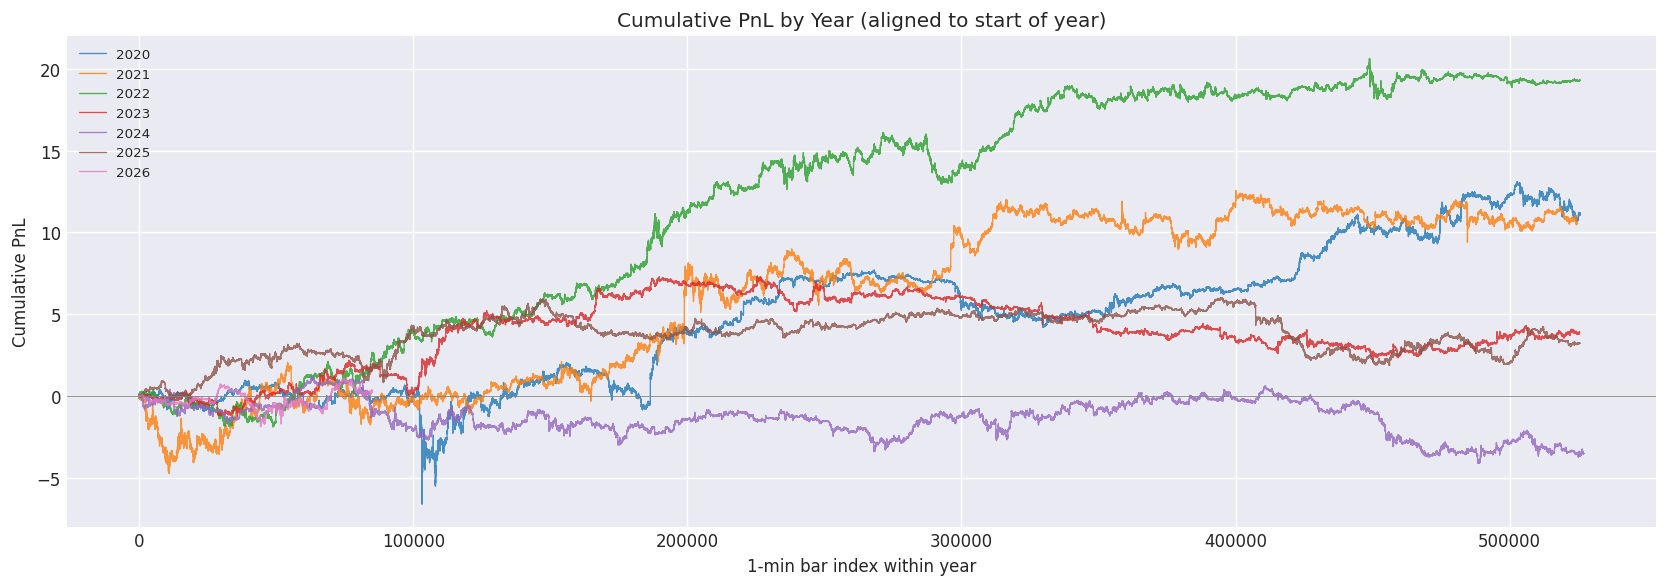

In [6]:
# By-year cumulative PnL overlay
fig, ax = plt.subplots(figsize=(14, 5))
for year in sorted(common.year.unique()):
    mask = common.year == year
    yr_pnl = pnl.loc[common[mask]]
    yr_cum = yr_pnl.cumsum()
    ax.plot(range(len(yr_cum)), yr_cum.values, label=str(year), linewidth=0.8, alpha=0.8)
ax.set_title("Cumulative PnL by Year (aligned to start of year)")
ax.set_ylabel("Cumulative PnL")
ax.set_xlabel("1-min bar index within year")
ax.axhline(0, color="gray", linewidth=0.5)
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

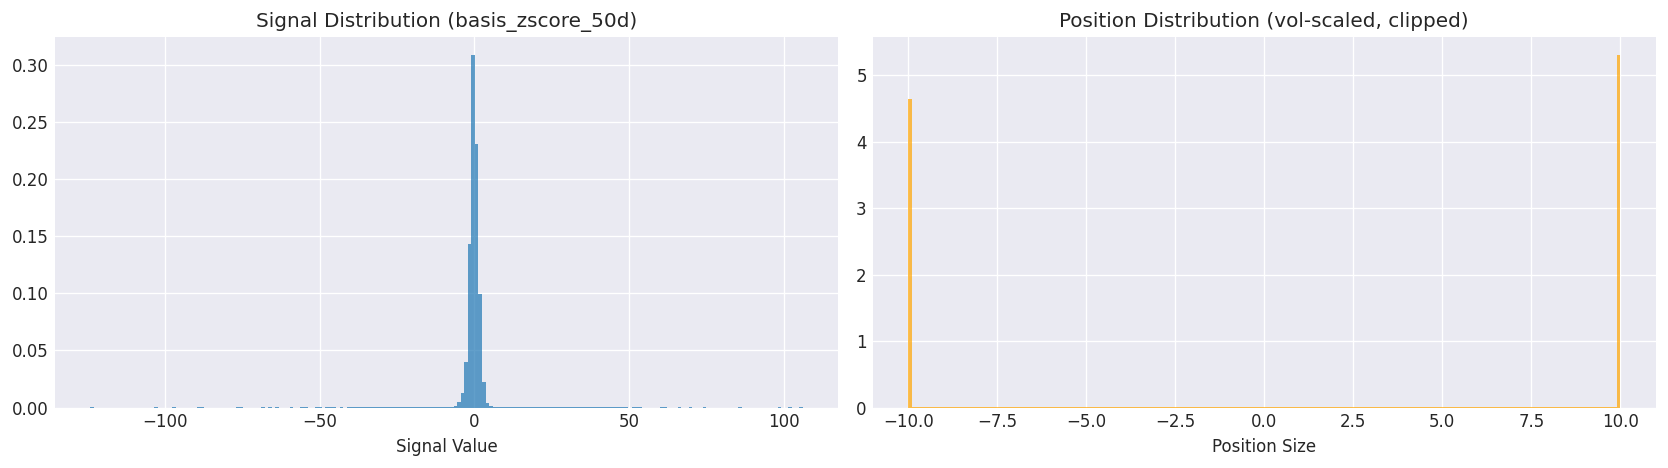

In [7]:
# Signal distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(sig.values, bins=200, density=True, alpha=0.7)
axes[0].set_title("Signal Distribution (basis_zscore_50d)")
axes[0].set_xlabel("Signal Value")

axes[1].hist(position.values, bins=200, density=True, alpha=0.7, color="orange")
axes[1].set_title("Position Distribution (vol-scaled, clipped)")
axes[1].set_xlabel("Position Size")

plt.tight_layout()
plt.show()